In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

## Классная работа

### nn.Conv2d

#### (batch_size, in_channels, H, W) -> nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0) -> (batch_size, out_channels, Hm, Wm)
- padding="valid" (padding=0)
- paddding='same (размер выходных карт будет такой же, как и у входных, H=Hm, W=Wm)

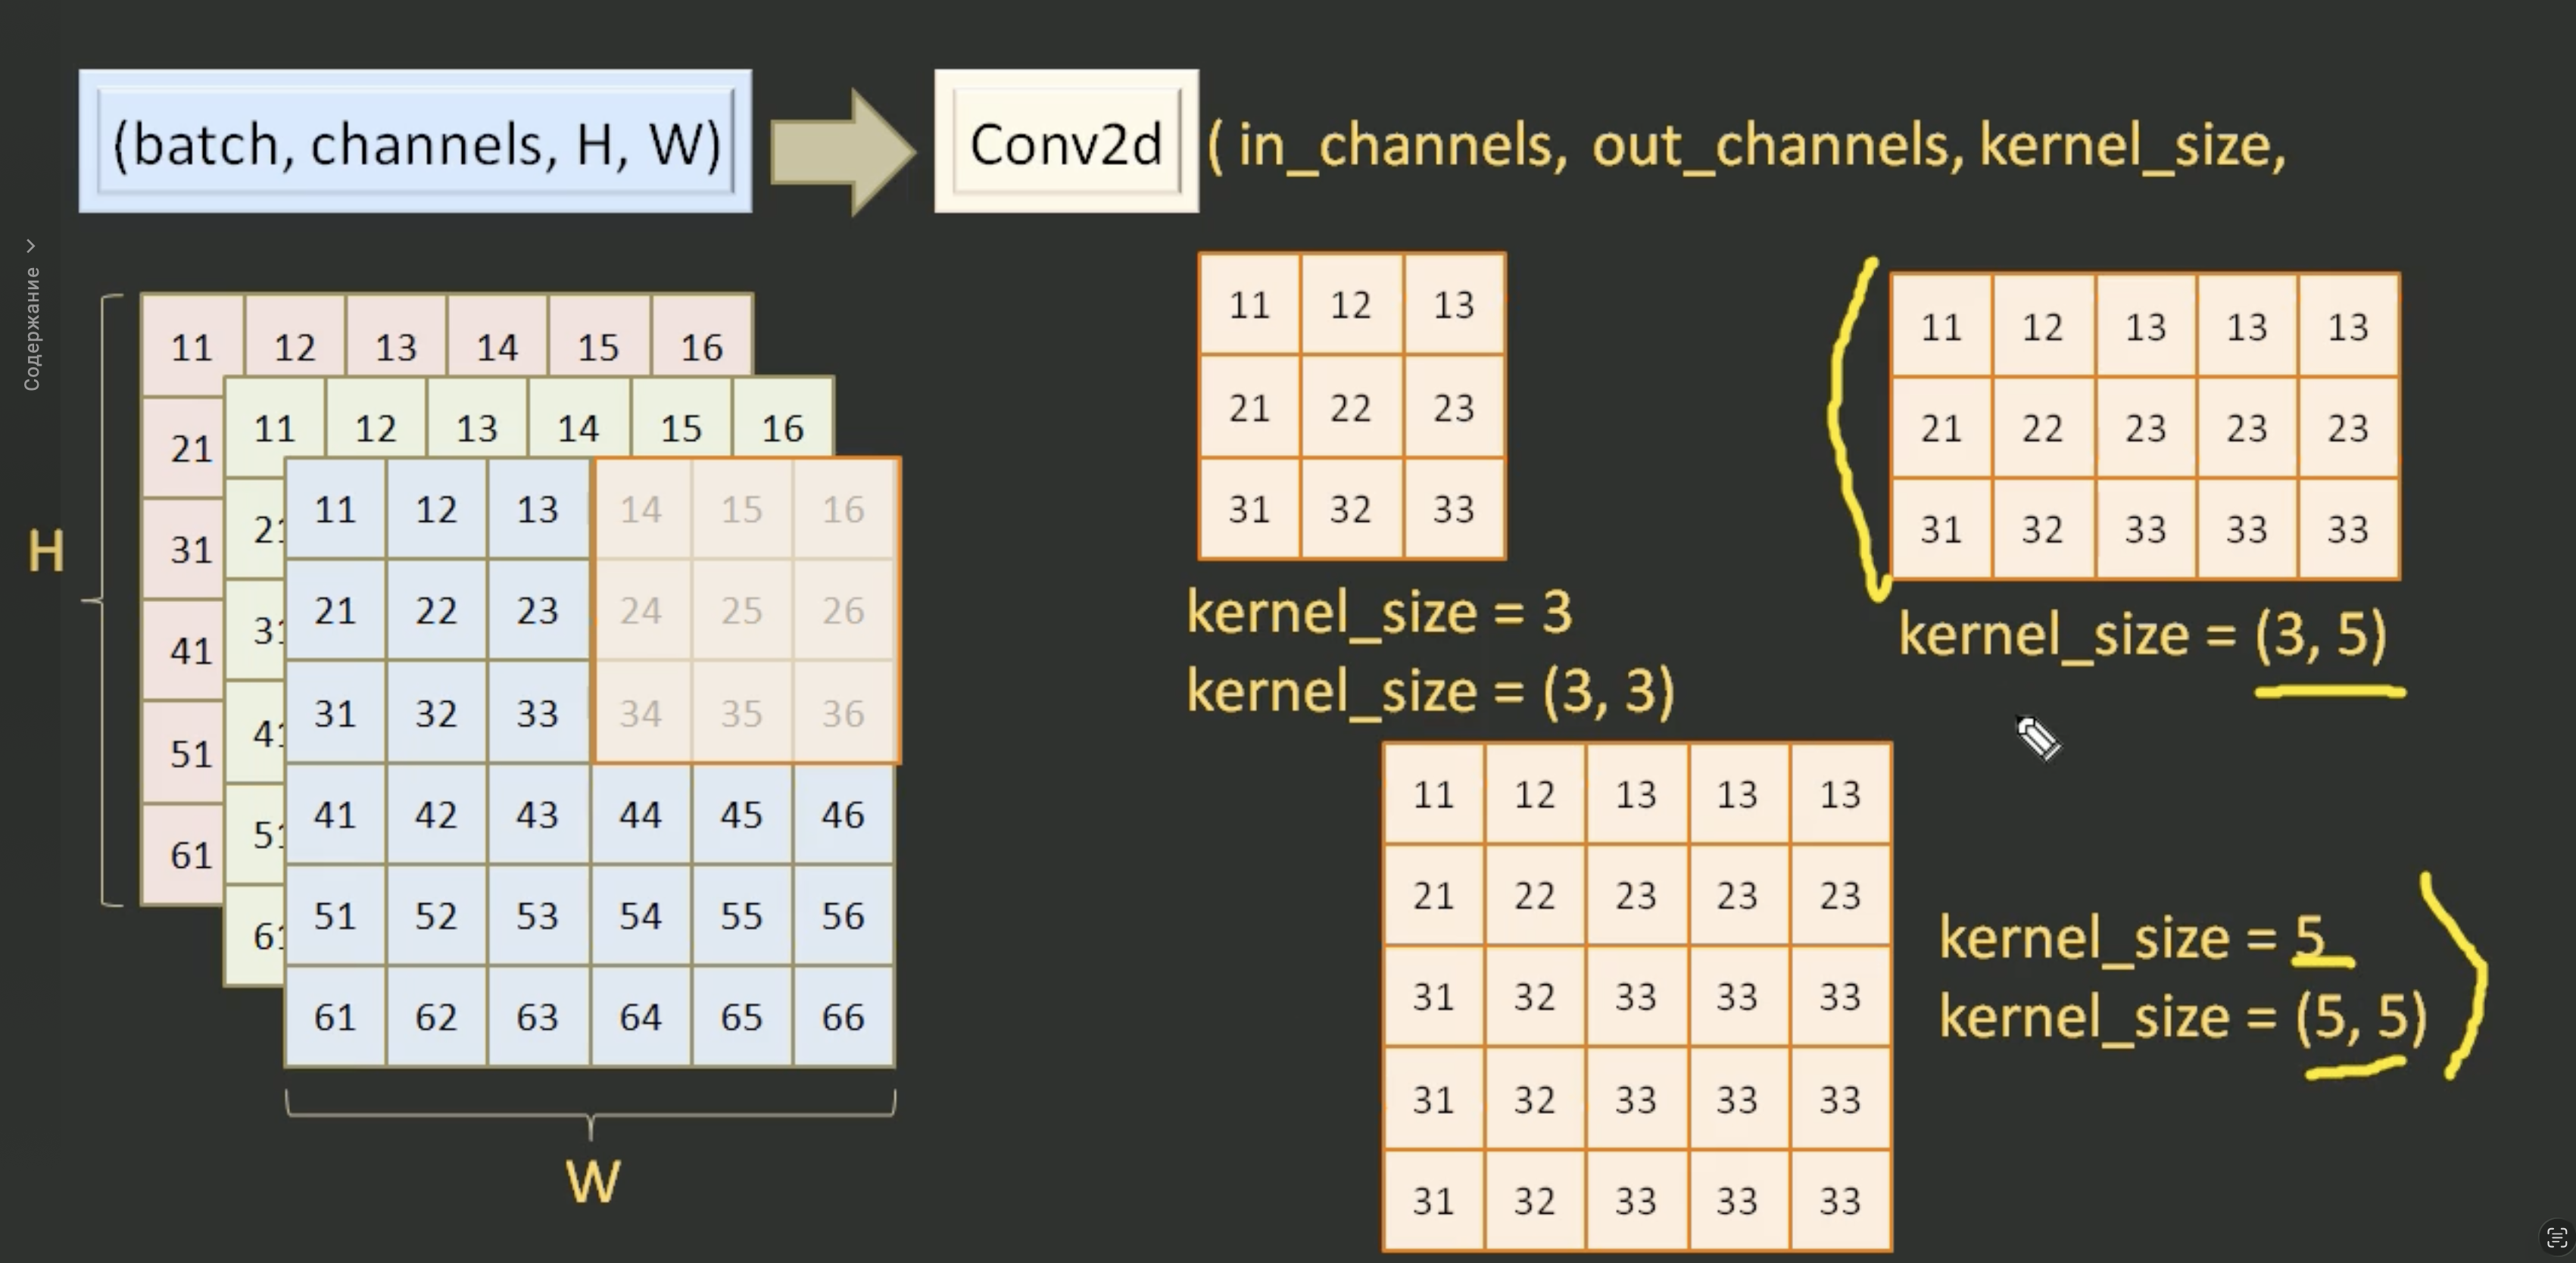

### nn.MaxPool2d(kernel_size, stride=None)

## Домашняя работа

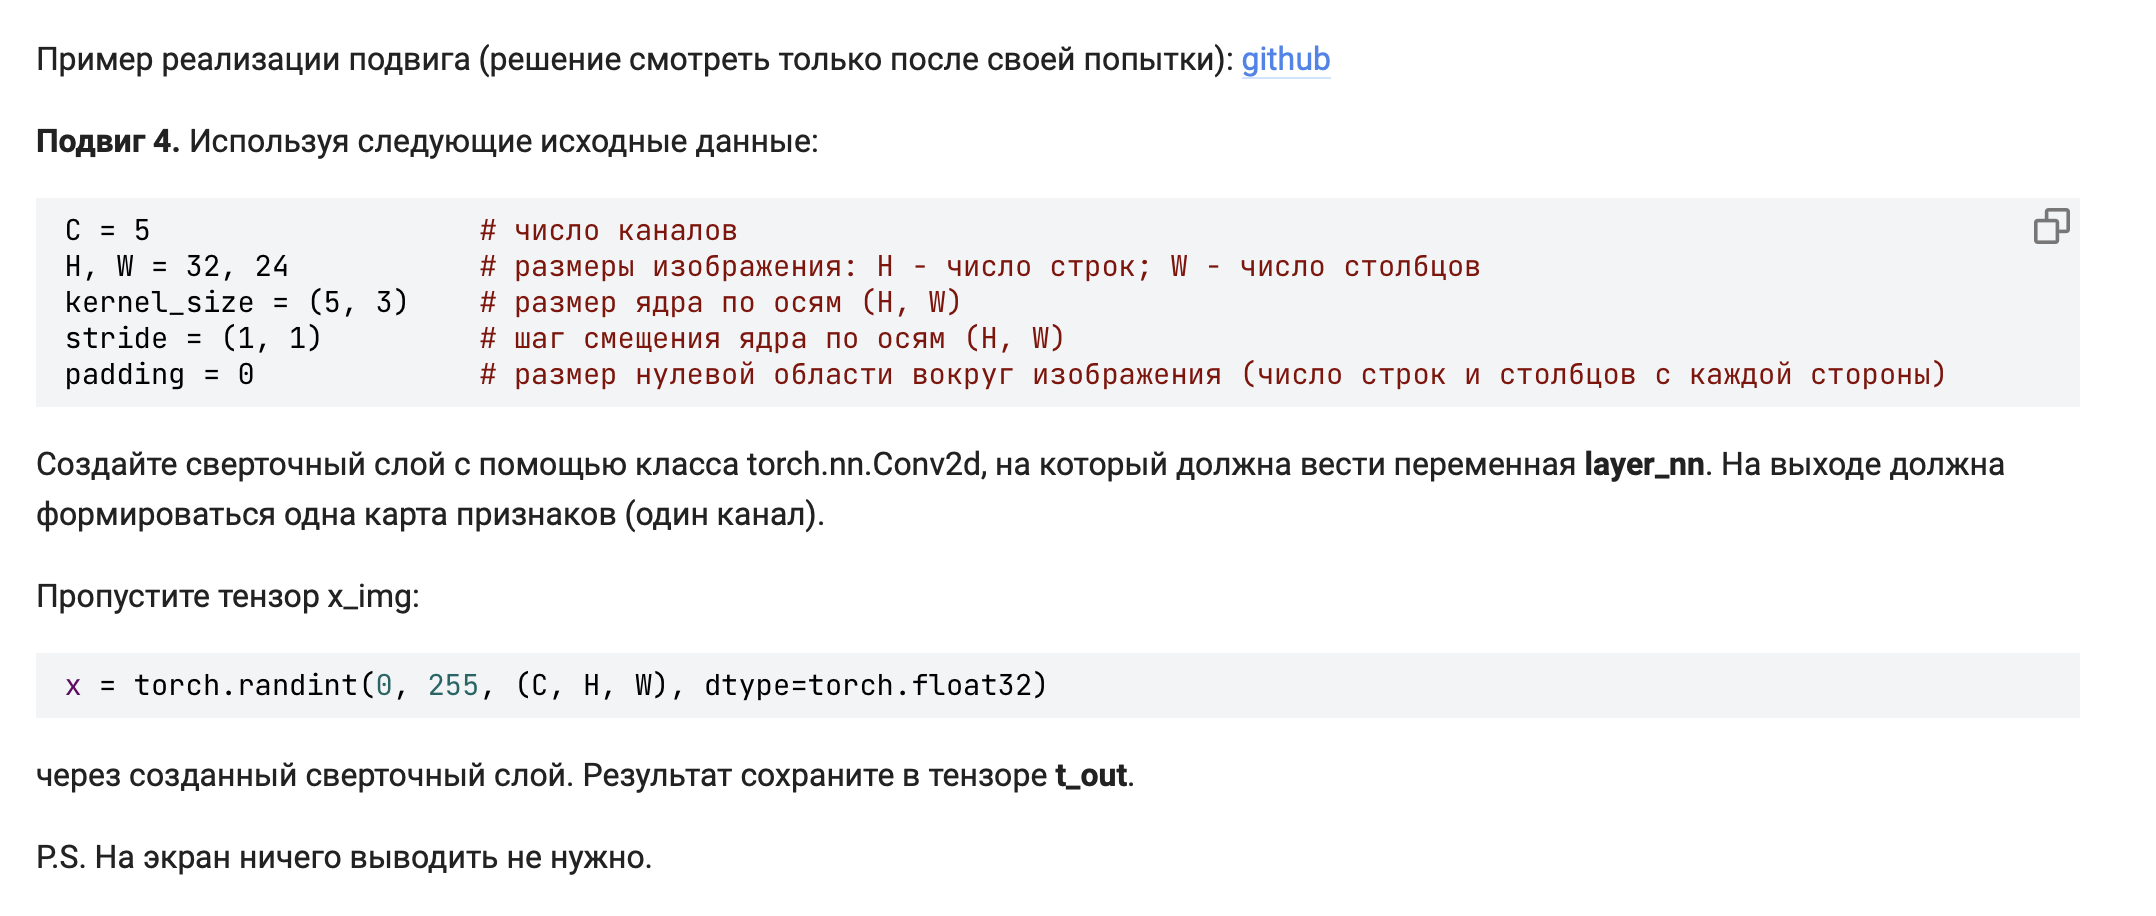

In [2]:
import torch
import torch.nn as nn

C = 5                   # число каналов
H, W = 32, 24           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (5, 3)    # размер ядра по осям (H, W)
stride = (1, 1)         # шаг смещения ядра по осям (H, W)
padding = 0             # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)


x = torch.randint(0, 255, (C, H, W), dtype=torch.float32) # тензор x в программе не менять

# здесь продолжайте программу
layer_nn = nn.Conv2d(in_channels=C, out_channels=1, kernel_size=kernel_size, stride=stride, padding=padding)
t_out = layer_nn(x)
t_out.shape

torch.Size([1, 28, 22])

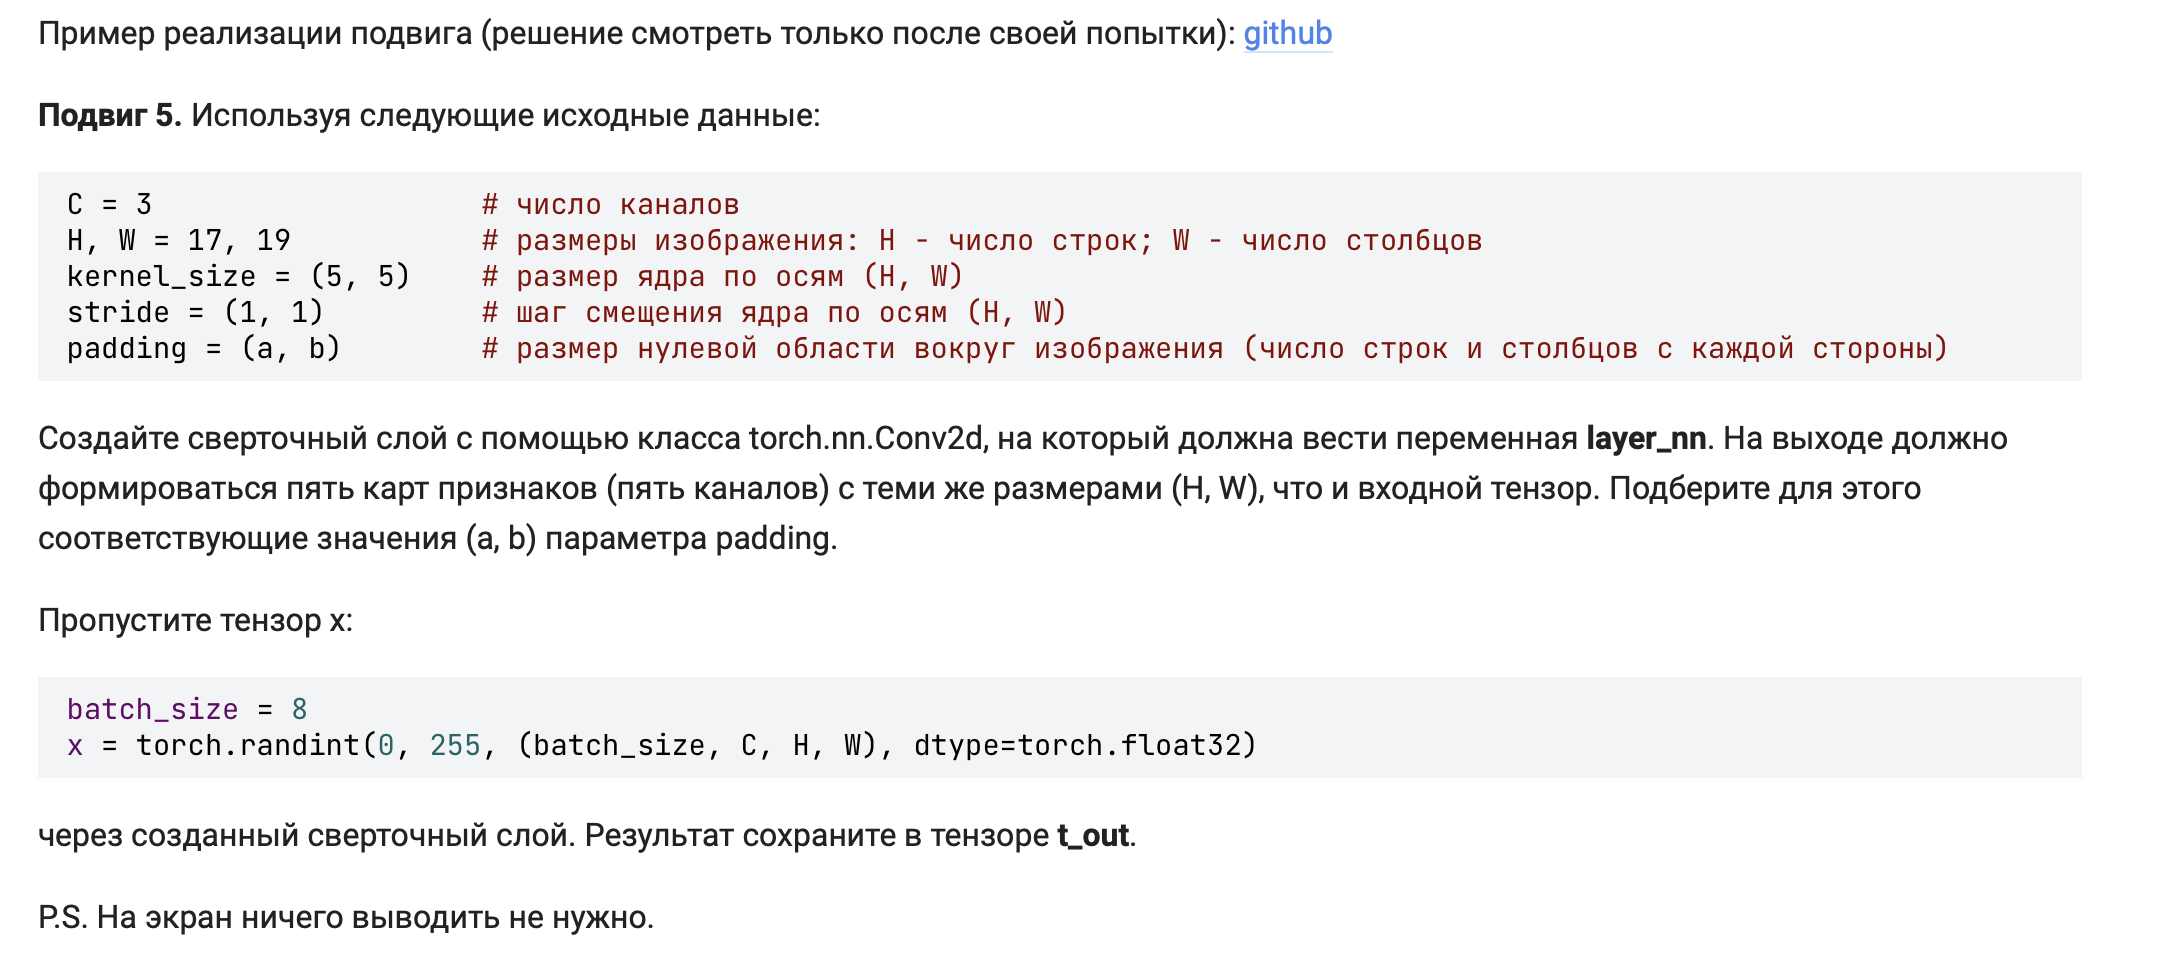

In [8]:
import torch
import torch.nn as nn

C = 3                   # число каналов
H, W = 17, 19           # размеры изображения: H - число строк; W - число столбцов
kernel_size = (5, 5)    # размер ядра по осям (H, W)
stride = (1, 1)         # шаг смещения ядра по осям (H, W)
padding = (2, 2)        # размер нулевой области вокруг изображения (число строк и столбцов с каждой стороны)

batch_size = 8
x = torch.randint(0, 255, (batch_size, C, H, W), dtype=torch.float32) # тензор x в программе не менять

# здесь продолжайте программу
layer_nn = nn.Conv2d(C, 5, kernel_size=kernel_size, stride=stride, padding=padding)
t_out = layer_nn(x)
t_out.shape

torch.Size([8, 5, 17, 19])

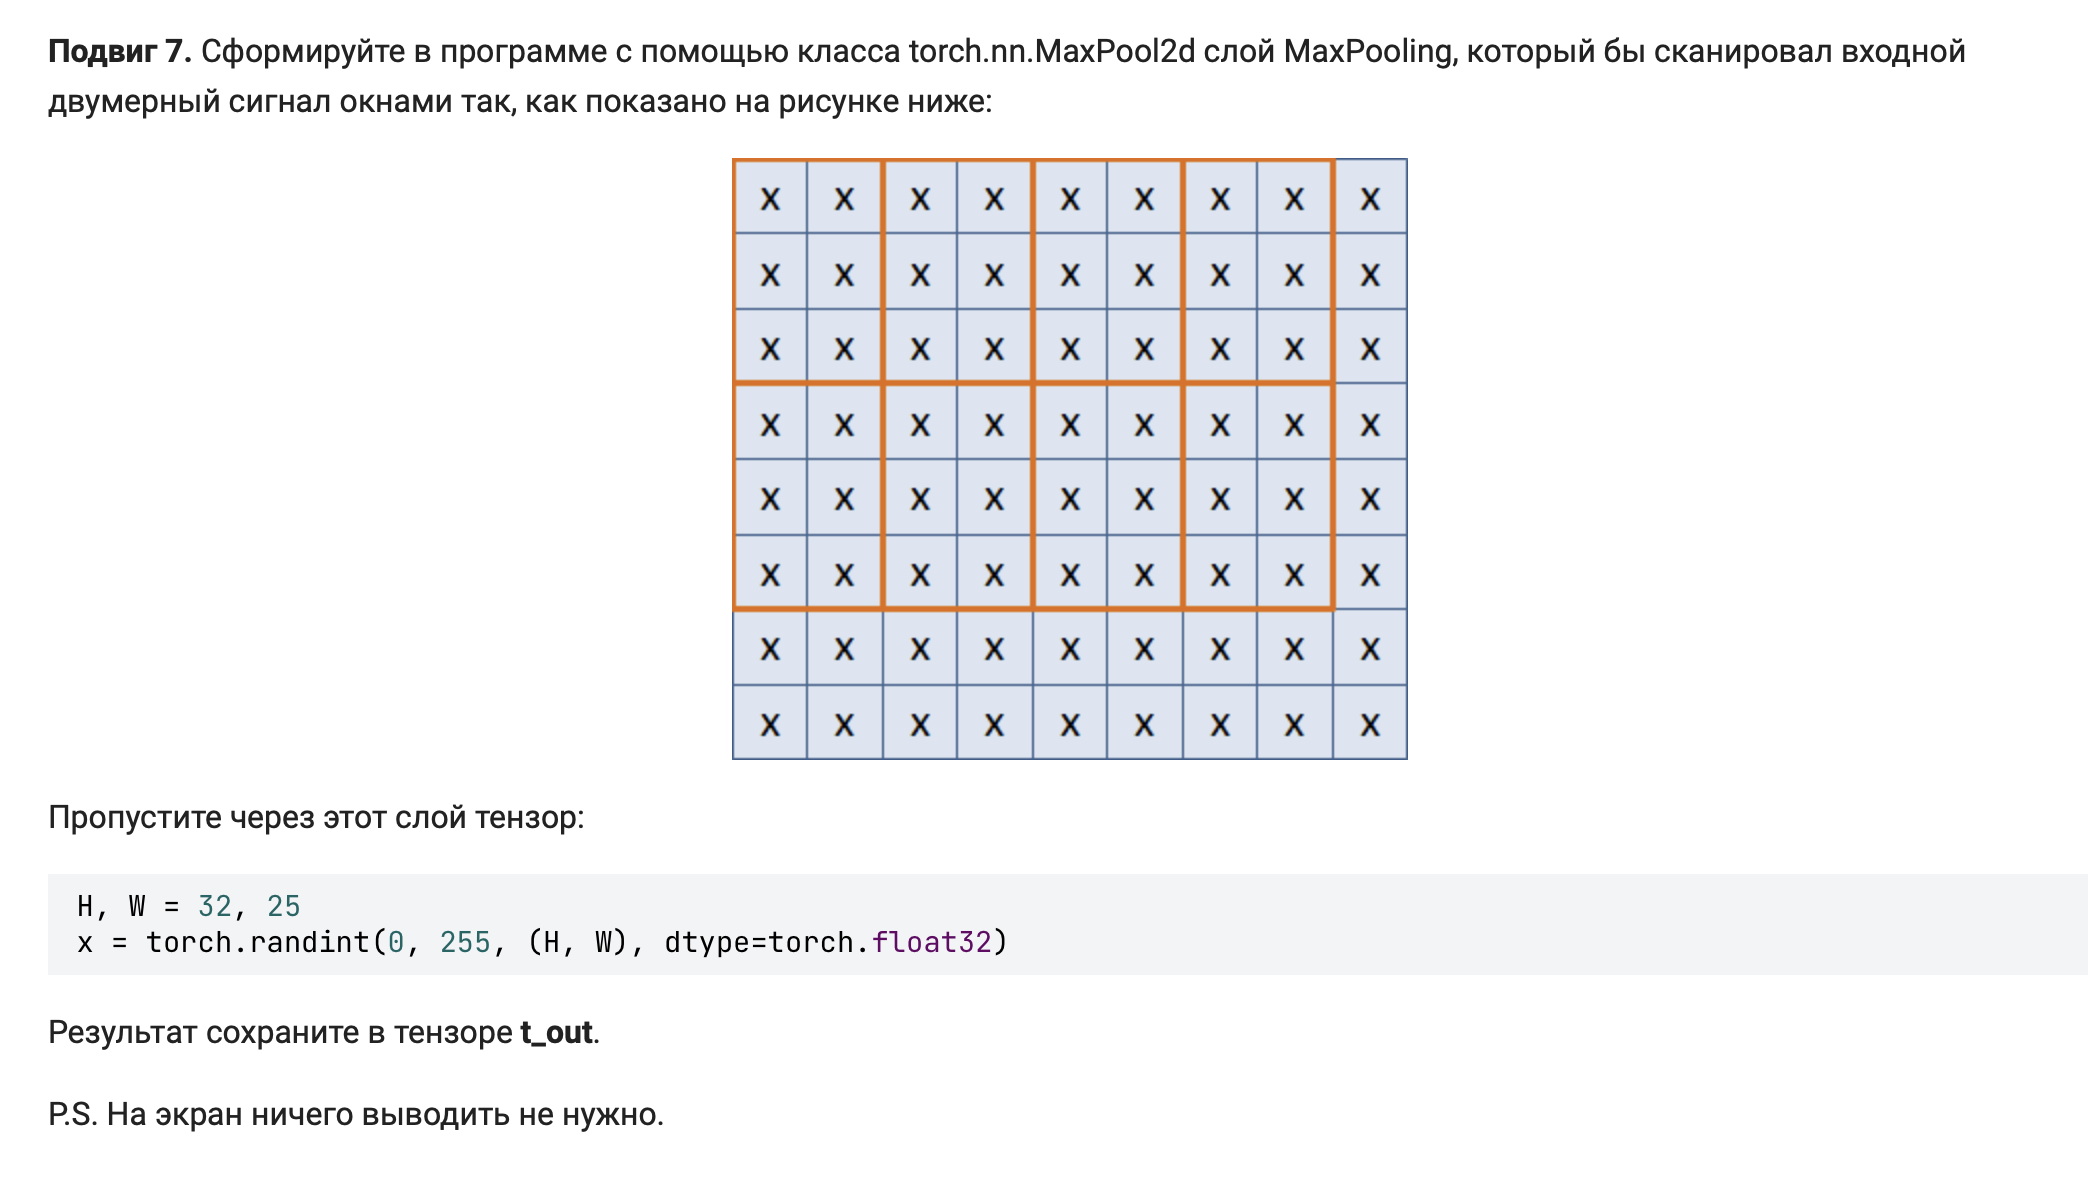

In [10]:
import torch
import torch.nn as nn

H, W = 32, 25
x = torch.randint(0, 255, (1, H, W), dtype=torch.float32) # тензор x в программе не менять

# здесь продолжайте программу
layer = nn.MaxPool2d((3, 2))
t_out = layer(x)
t_out.shape

torch.Size([1, 10, 12])

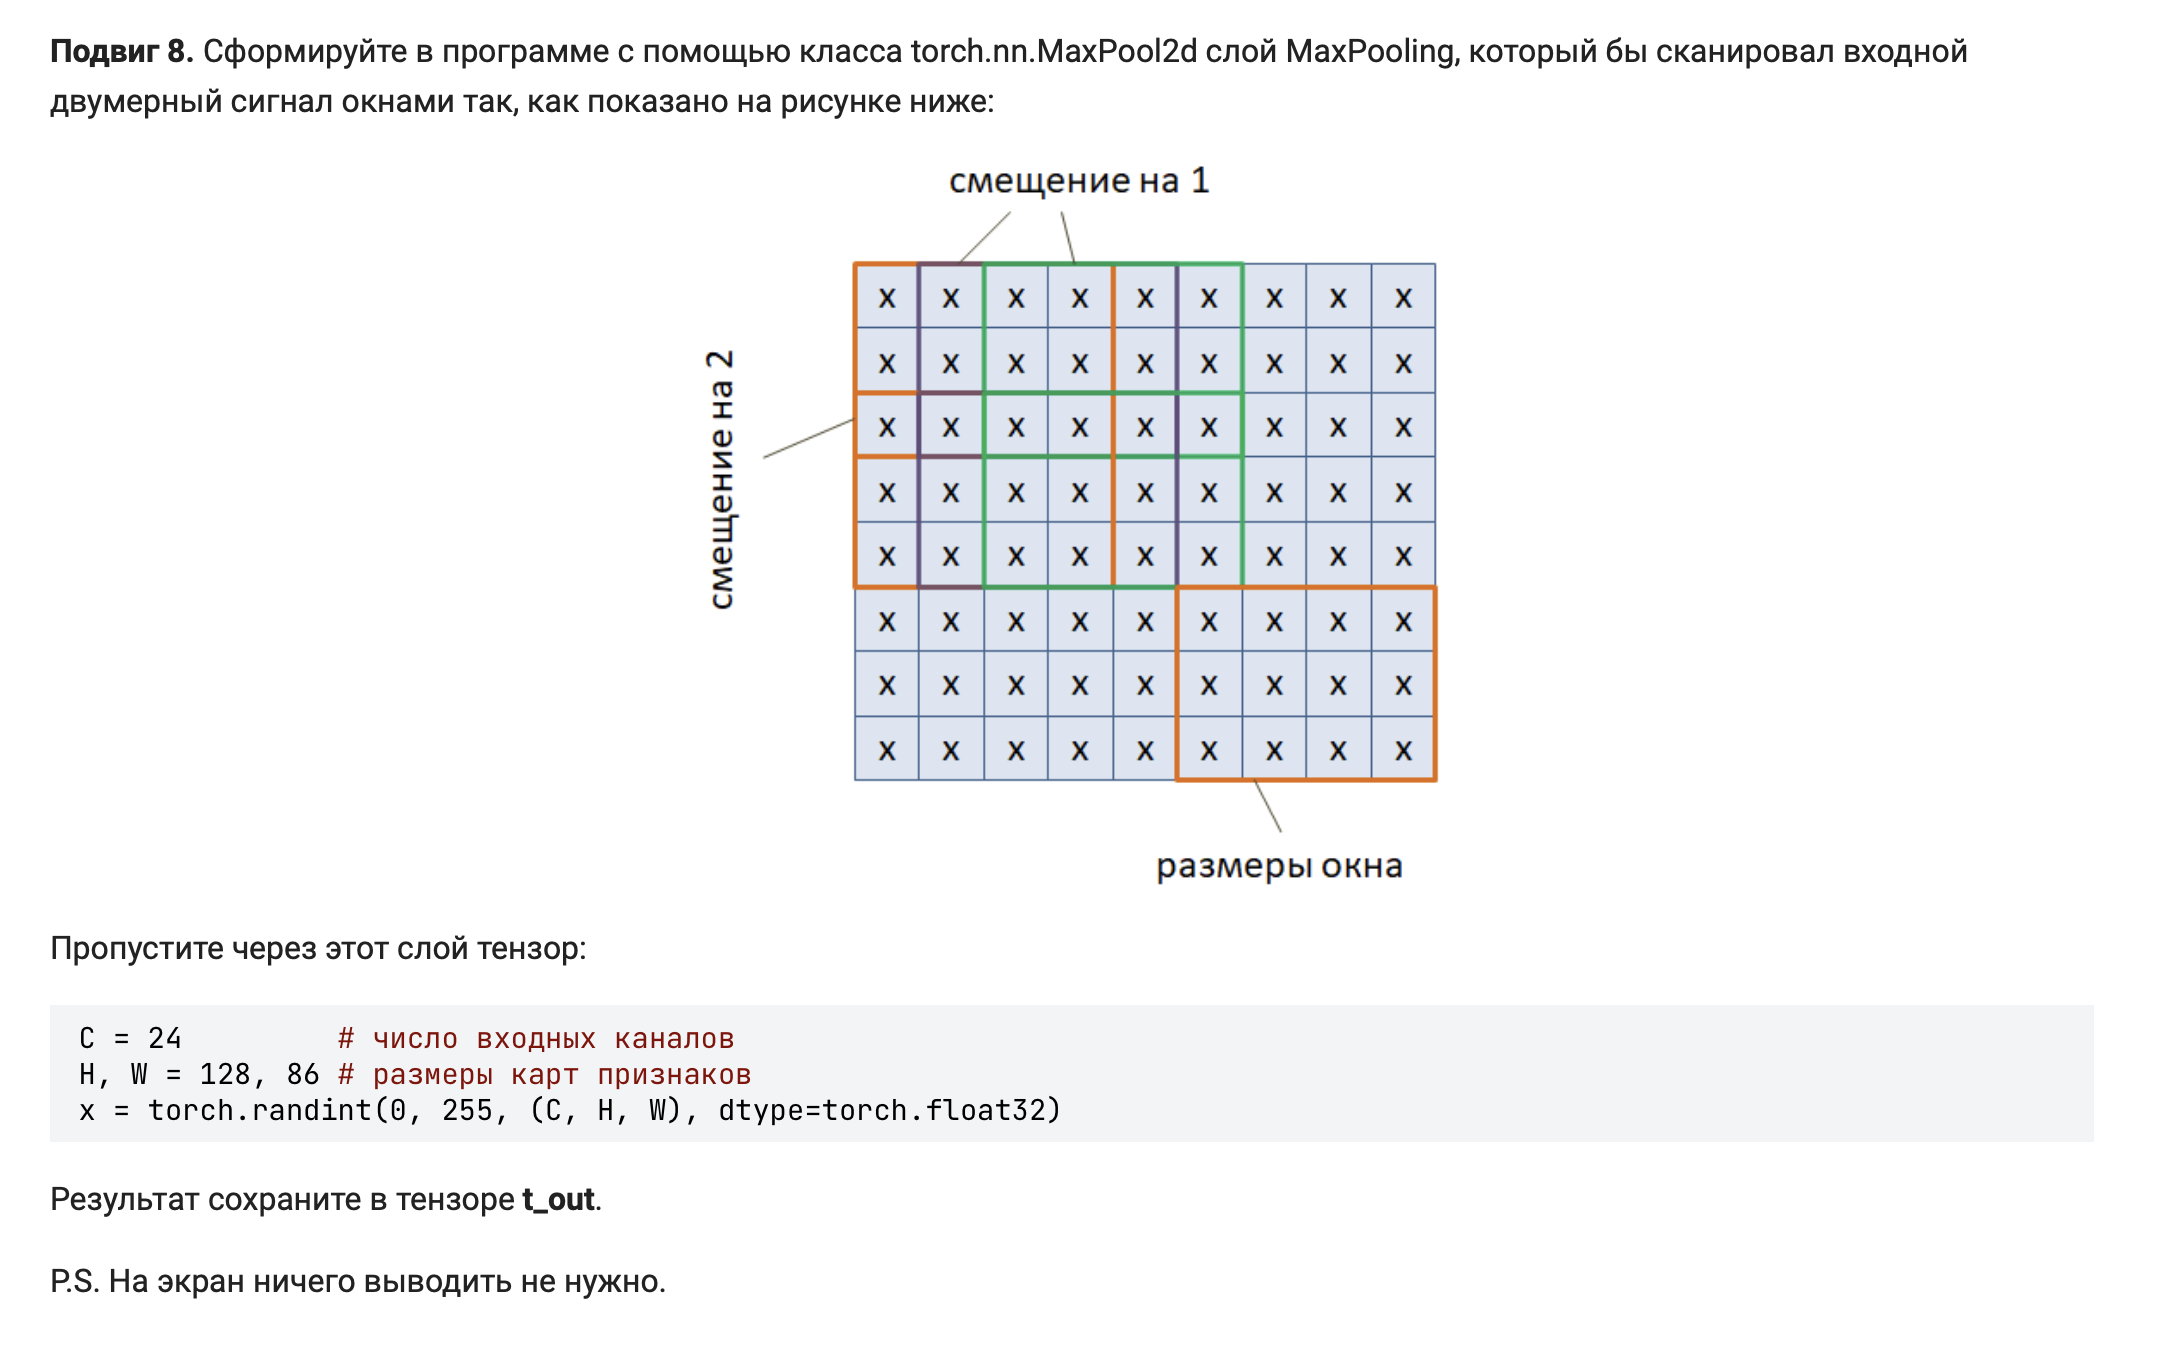

In [12]:
import torch
import torch.nn as nn

C = 24         # число входных каналов
H, W = 128, 86 # размеры карт признаков
x = torch.randint(0, 255, (C, H, W), dtype=torch.float32) # тензор x в программе не менять

# здесь продолжайте программу
layer = nn.MaxPool2d((3, 4), stride=(2, 1))
t_out = layer(x)
t_out.shape

torch.Size([24, 63, 83])

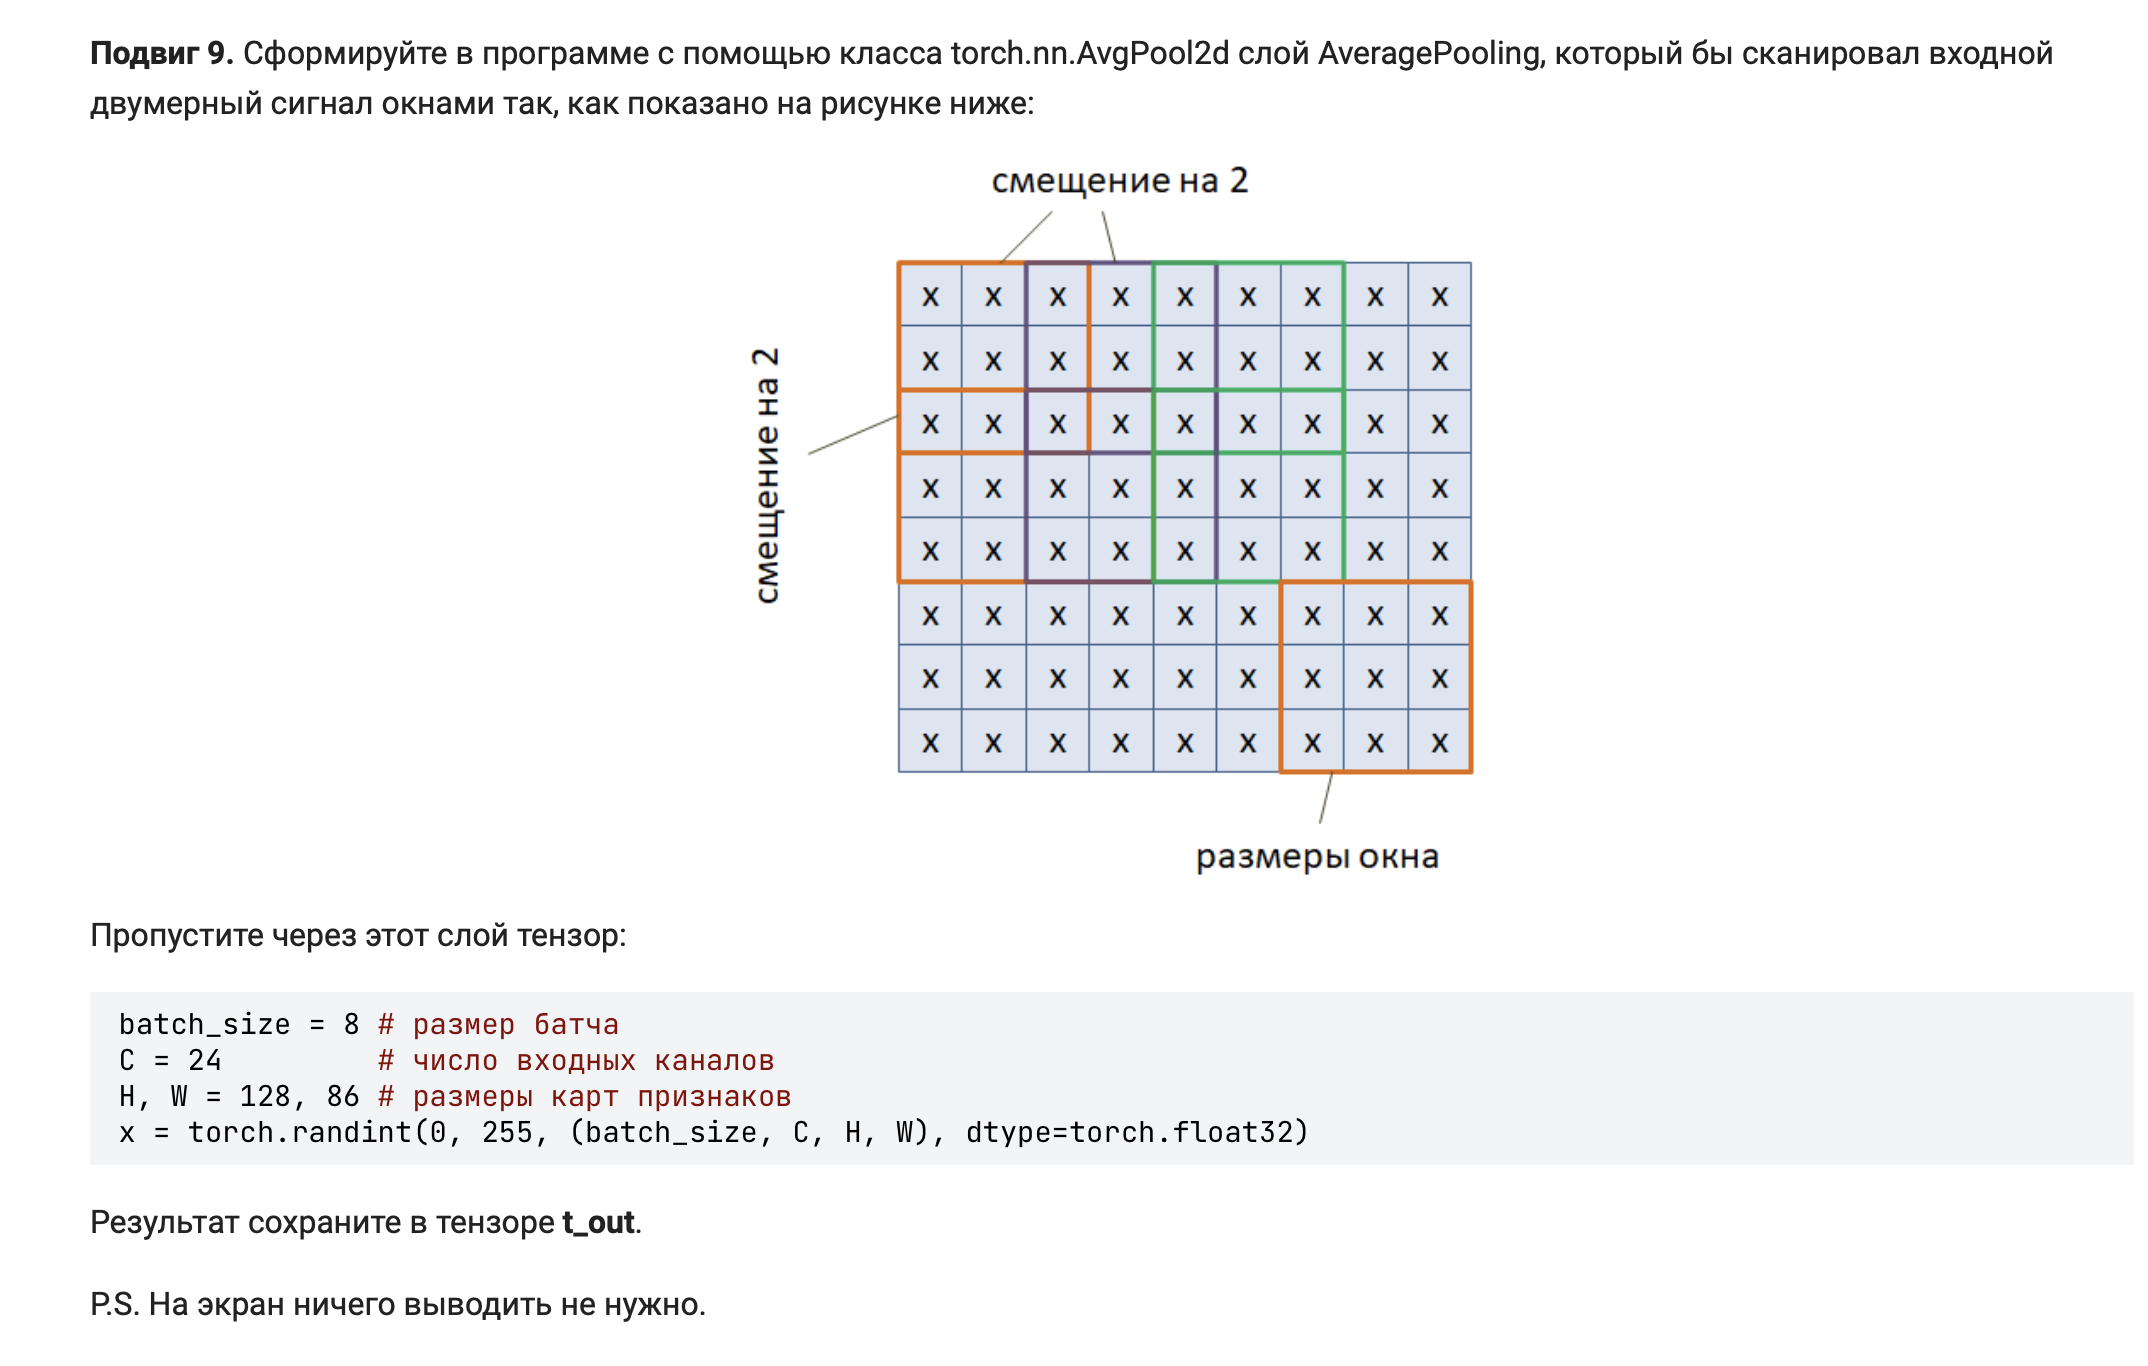

In [18]:
import torch
import torch.nn as nn

batch_size = 8 # размер батча
C = 24         # число входных каналов
H, W = 128, 86 # размеры карт признаков
x = torch.randint(0, 255, (batch_size, C, H, W), dtype=torch.float32) # тензор x в программе не менять

# здесь продолжайте программу
layer = nn.AvgPool2d((3, 3), stride=2)
t_out = layer(x)

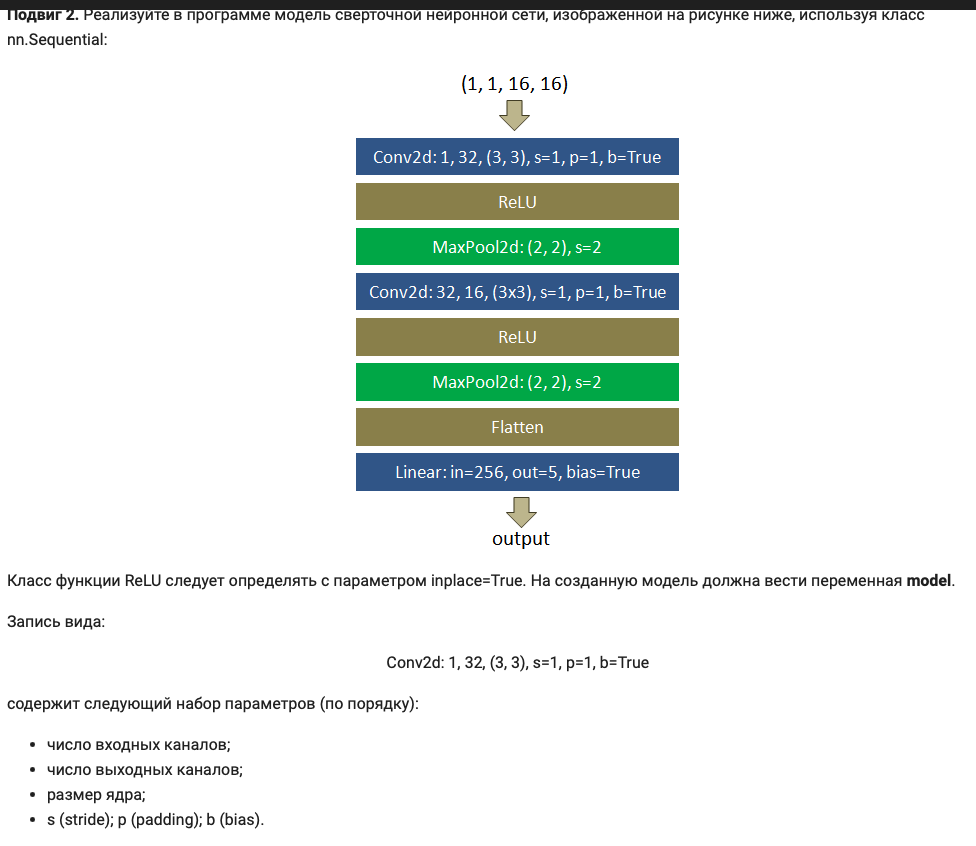
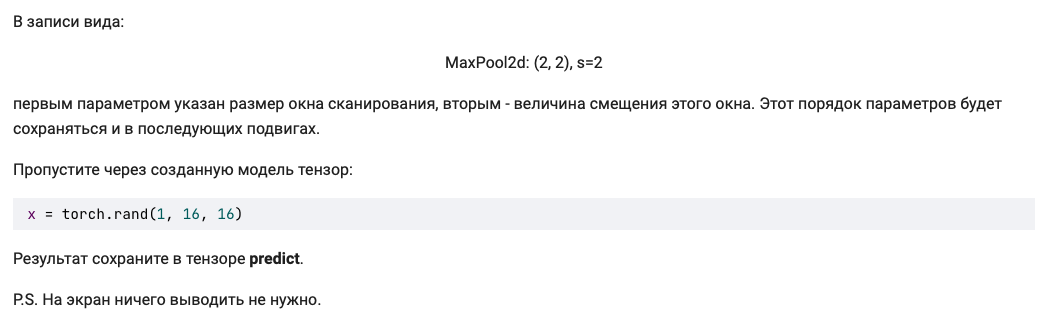

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 3, stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 16, 3, stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(256, 5)
)

x = torch.rand(1, 16, 16) # тензор x в программе не менять

predict = model(x.unsqueeze(0))

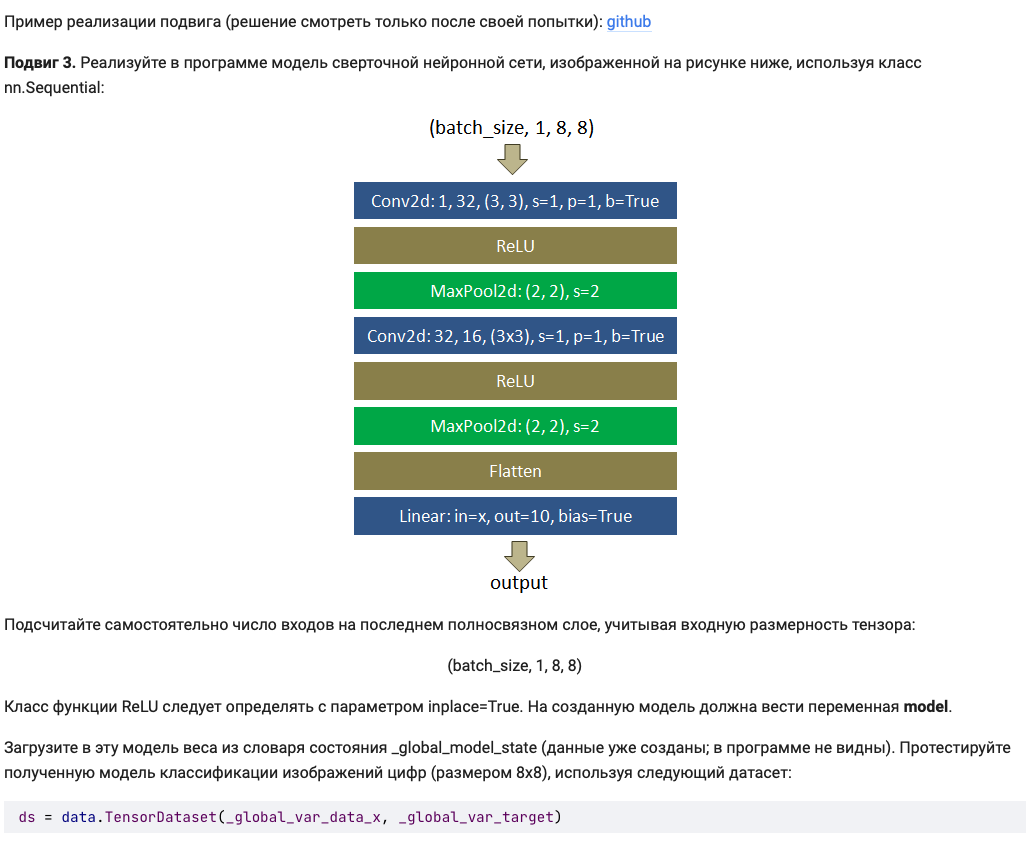
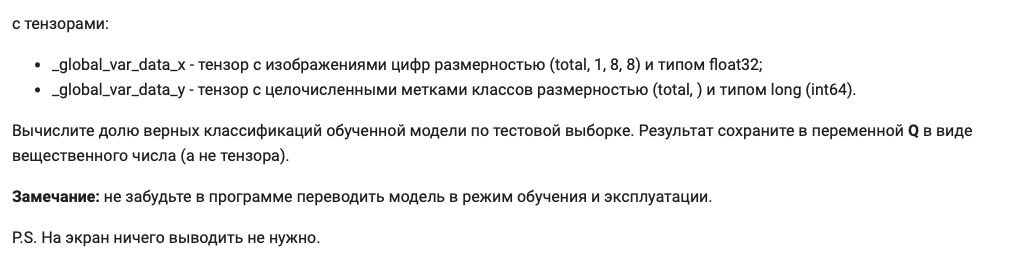

In [5]:
from sklearn.datasets import load_digits
import torch


digits = load_digits()

# Признаки и целевые значения
_global_var_data_x = torch.tensor(digits.data, dtype=torch.float32).view(-1, 1, 8, 8)
_global_var_target = torch.tensor(digits.target, dtype=torch.int64)

In [ ]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

ds = data.TensorDataset(_global_var_data_x, _global_var_target)

# здесь продолжайте программу
model = nn.Sequential(
    nn.Conv2d(1, 32, 3, stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 16, 3, stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64, 10)
)

model.load_state_dict(_global_model_state)
model.eval()
data_test = data.DataLoader(ds, batch_size=len(ds), shuffle=False)

for x_test, y_test in data_test:
    pred = model(x_test)

    pred = pred.argmax(dim=1)

    Q = torch.mean((pred == y_test).float()).item()

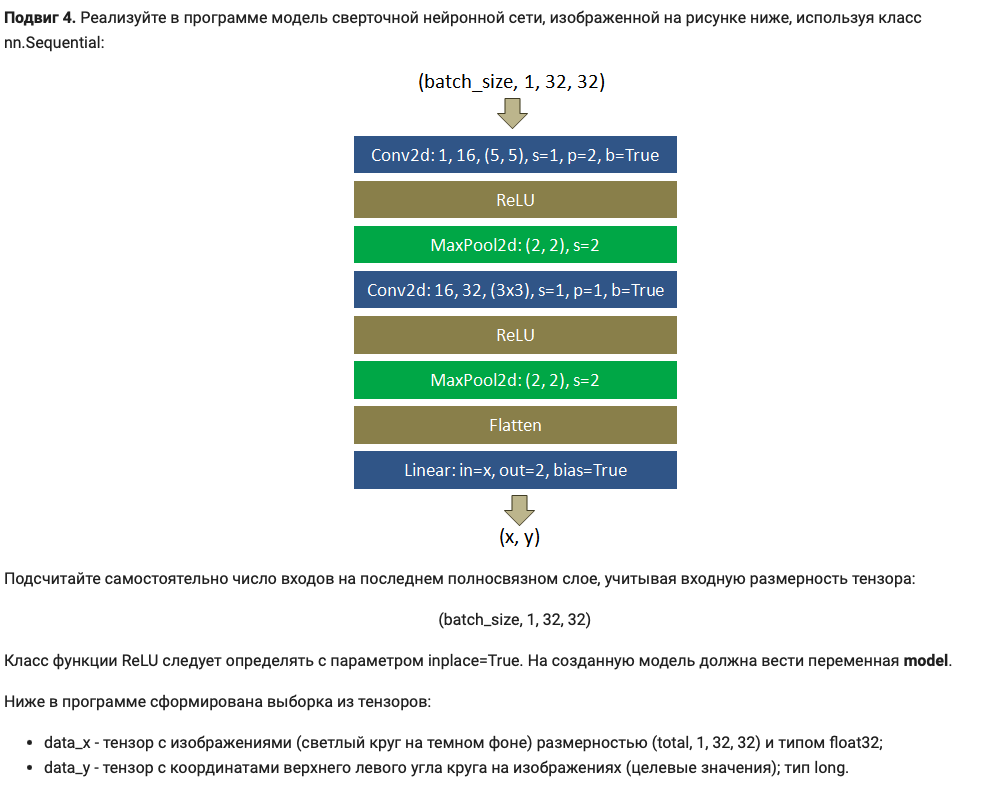
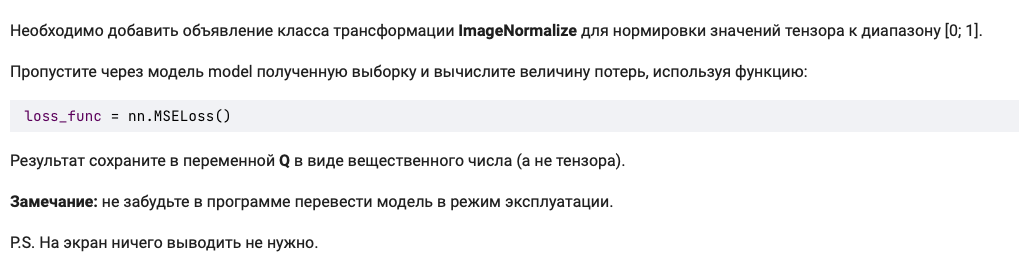

In [18]:
import torch
import torch.nn as nn

# здесь объявляйте класс ImageNormalize

# генерация образов выборки
total = 100 # размер выборки
H, W = 32, 32 # размер изображений
circle = torch.tensor([[0, 0, 0, 255, 255, 255, 255, 0, 0, 0],
                       [0, 255, 255, 255, 255, 255, 255, 255, 255, 0],
                       [0, 255, 255, 255, 255, 255, 255, 255, 255, 0],
                       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
                       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
                       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
                       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
                       [0, 255, 255, 255, 255, 255, 255, 255, 255, 0],
                       [0, 255, 255, 255, 255, 255, 255, 255, 255, 0],
                       [0, 0, 0, 255, 255, 255, 255, 0, 0, 0]], dtype=torch.float32)
Hc, Wc = circle.size()


def _generate_img(_H, _W, _Hc, _Wc, _x, _y, _circle, _tr): # вспомогательная функция
    img = torch.rand(_H, _W) * 20
    img[_x:_x+_Hc, _y:_y+Wc] = _circle
    return _tr(img.view(1, 1, _H, _W))

class ImageNormalize(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x / 256.


transform = ImageNormalize() # создайте объект класса ImageNormalize
data_y = torch.tensor([(torch.randint(0, H-Hc, (1, )), torch.randint(0, W-Wc, (1, ))) for _ in range(total)])
data_x = torch.cat([_generate_img(H, W, Hc, Wc, _x[0], _x[1], circle, transform) for _x in data_y], dim=0)

torch.manual_seed(1)
# здесь создавайте модель (обязательно сразу после команды torch.manual_seed(1))
model = nn.Sequential(
    nn.Conv2d(1, 16, 5, stride=1, padding=2, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(16, 32, 3, stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64*32, 2)
)
model.eval()
# пропустите через модель выборку data_x
pred = model(data_x)
loss_func = nn.MSELoss()
Q = loss_func(pred, data_y) # вычислите величину потерь, используя функцию loss_func = nn.MSELoss()

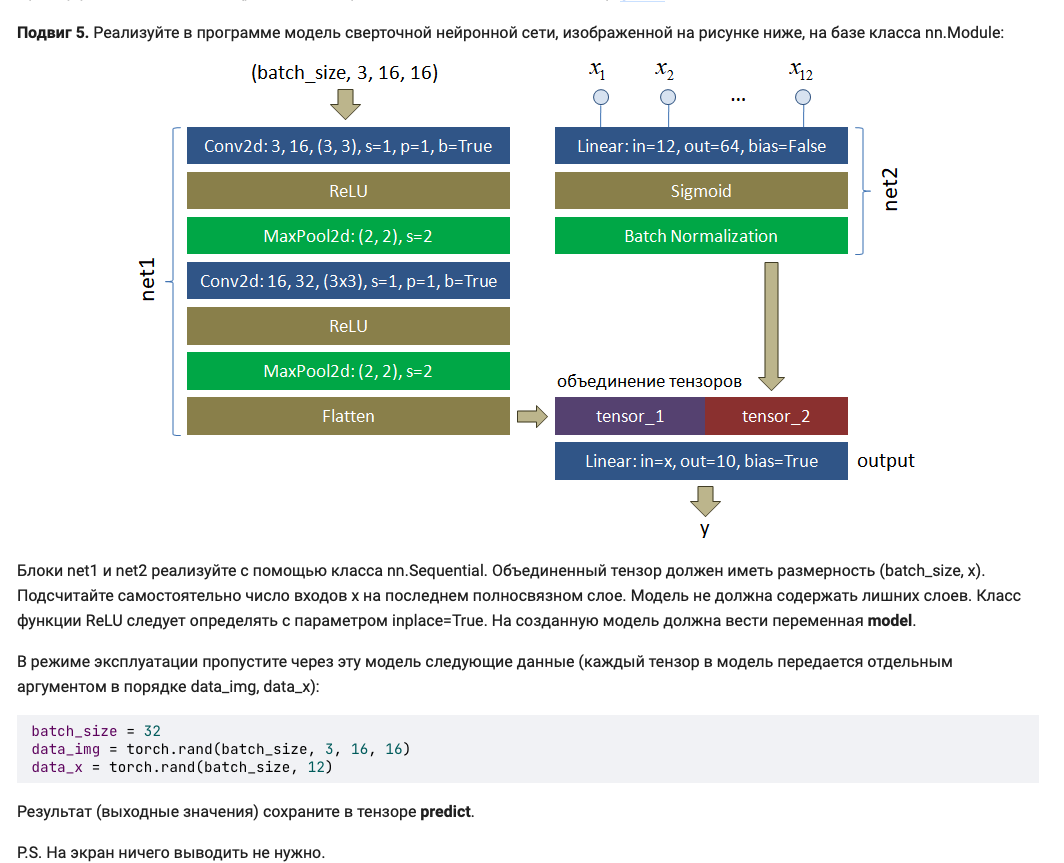

In [31]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.net1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Flatten()
        )

        self.net2 = nn.Sequential(
            nn.Linear(12, 64, bias=False),
            nn.Sigmoid(),
            nn.BatchNorm1d(64)
        )

        self.output = nn.Linear(64+32*16, 10)

    def forward(self, img, x):
        x1 = self.net1(img)
        x2 = self.net2(x)

        x = torch.concat([x1, x2], dim=1)
        x = self.output(x)

        return x



# тензоры data_img, data_x в программе не менять
batch_size = 32
data_img = torch.rand(batch_size, 3, 16, 16)
data_x = torch.rand(batch_size, 12)

# здесь продолжайте программу
model = Model()
model.eval()
predict = model(data_img, data_x)